# 1
Load the dataset into a Pandas DataFrame.

In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


# 2
Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [ ]:
print(df.head())

print(df.info())

print(df.describe(include='all')) #saves time doing each individually

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# 3
Drop any non-informative identifiers (such as customerID).

In [ ]:
df = df.drop(columns=["customerID"]) #thats it!

# 4
Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [ ]:
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True) #this regex took awhile to figure out
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

missing = df.isnull().sum()

print(missing)

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
import numpy as np

num_imputer = SimpleImputer(strategy="median") #seems good


cat_imputer = SimpleImputer(strategy="most_frequent") #making a third category seems over the top here

transformer = ColumnTransformer(
  transformers=[
    ("number_rule", num_imputer, make_column_selector(dtype_include=np.number)),
    ("word_rule", cat_imputer, make_column_selector(dtype_include=object),),
  ]
)
transformer.set_output(transform="pandas")

ColumnTransformer(transformers=[('number_rule',
                                 SimpleImputer(strategy='median'),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x786e1c9bab70>),
                                ('word_rule',
                                 SimpleImputer(strategy='most_frequent'),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x786e1cb4f0b0>)])

# 5
Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

scaling_pipeline = ColumnTransformer([
    ("num", StandardScaler(), make_column_selector(dtype_include=np.number)),
    ("cat", OneHotEncoder(sparse_output=False), make_column_selector(dtype_include=object),)
])
scaling_pipeline.set_output(transform="pandas")

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x786e1bd1eeb0>),
                                ('cat', OneHotEncoder(sparse_output=False),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x786e1bd1ec10>)])

# 6

Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline

full_pipeline = make_pipeline(
    transformer,
    scaling_pipeline,
    SGDClassifier(max_iter=1000, tol=1e-3, loss='log_loss'),
)

# 7
Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.


1. Confusion matrix:
[[861 174]
 [148 226]]

2. Classification report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1035
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

3. ROC-AUC score: 0.8181559843963936

1. Confusion matrix:
[[1410  142]
 [ 273  288]]

2. Classification report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1552
           1       0.67      0.51      0.58       561

    accuracy                           0.80      2113
   macro avg       0.75      0.71      0.73      2113
weighted avg       0.79      0.80      0.79      2113

3. ROC-AUC score: 0.8382571163423195

1. Confusion matrix:
[[1877  193]
 [ 389  359]]

2. Classification report:
              precision    recall  f1-score   su

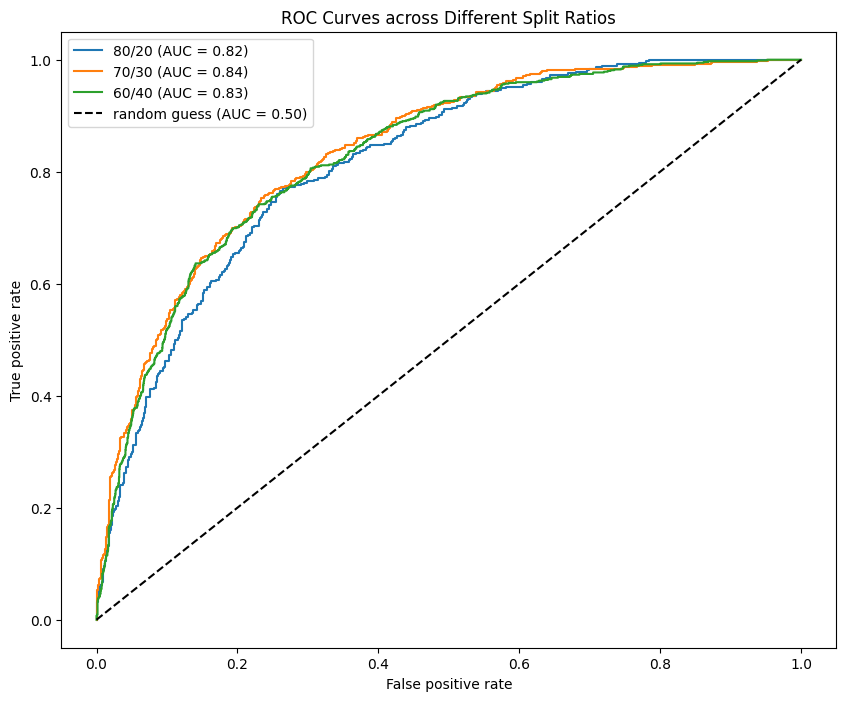

In [ ]:
# note to self: truly, this is "draw the rest of the owl" incarnate
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

x = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

split_ratios = {
    "80/20": 0.20,
    "70/30": 0.30,
    "60/40": 0.40
}


plt.figure(figsize=(10, 8))



for label, test_size_pct in split_ratios.items():
  X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=test_size_pct, stratify=y
  )
  full_pipeline.fit(X_train, y_train)

  y_prediction = full_pipeline.predict(X_test)
  y_probability = full_pipeline.predict_proba(X_test)[:, 1] # for "rock hawk" aka ROC-AUC

  print("\n1. Confusion matrix:")
  print(confusion_matrix(y_test, y_prediction))

  print("\n2. Classification report:")
  print(classification_report(y_test, y_prediction))

  auc_score = roc_auc_score(y_test, y_probability)
  print(f"3. ROC-AUC score: {auc_score}")

  fpr, tpr, _ = roc_curve(y_test, y_probability)
  plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_score:.2f})")


plt.plot([0, 1], [0, 1], 'k--', label="random guess (AUC = 0.50)")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curves across Different Split Ratios")
plt.legend()
plt.show()

# 8
Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.

In [ ]:
feature_names = full_pipeline.named_steps['columntransformer-2'].get_feature_names_out()
#thank you for automatically naming the steps scikit very helpful

coefficients = full_pipeline.named_steps['sgdclassifier'].coef_[0]

weights = {} #sort them by importance
for name, coef in zip(feature_names, coefficients):
    weights[name] = coef

#abs() because absolute value is what we care about
sorted_weights = sorted(weights.items(), key=lambda item: abs(item[1]), reverse=True)

for name, coef in sorted_weights:
  clean_name = name.replace("cat__word_rule__", "").replace("num__number_rule__", "")
  print(f"{clean_name}: {coef:.4f}")


tenure: -1.5295
Contract_Month-to-month: 1.1806
InternetService_Fiber optic: 0.9596
TotalCharges: 0.8592
PaperlessBilling_Yes: 0.7944
OnlineSecurity_No: 0.7762
gender_Male: 0.6436
Dependents_No: 0.6366
PaymentMethod_Electronic check: 0.6363
StreamingTV_Yes: 0.6286
TechSupport_No: 0.6285
PhoneService_No: 0.6158
MultipleLines_No phone service: 0.6158
Partner_Yes: 0.5975
OnlineBackup_No: 0.5289
DeviceProtection_No: 0.5198
Contract_Two year: -0.4877
Partner_No: 0.4492
StreamingMovies_Yes: 0.4329
PhoneService_Yes: 0.4309
Dependents_Yes: 0.4101
gender_Female: 0.4031
Contract_One year: 0.3538
StreamingMovies_No: 0.3512
MonthlyCharges: -0.2923
PaymentMethod_Mailed check: 0.2893
MultipleLines_Yes: 0.2661
DeviceProtection_Yes: 0.2644
InternetService_No: 0.2625
OnlineSecurity_No internet service: 0.2625
OnlineBackup_No internet service: 0.2625
DeviceProtection_No internet service: 0.2625
TechSupport_No internet service: 0.2625
StreamingTV_No internet service: 0.2625
StreamingMovies_No internet se